In [11]:
import pandas as pd
df =pd.read_csv("ipl_dummy_dataset.csv")
#Task 1 Data Understanding
newdf=df.head(5)
print(df)

      id  season       city                        team1  \
0      1    2018    Chennai               Mumbai Indians   
1      2    2018     Jaipur               Delhi Capitals   
2      3    2018  Bangalore  Royal Challengers Bangalore   
3      4    2018      Delhi          Chennai Super Kings   
4      5    2018    Kolkata  Royal Challengers Bangalore   
..   ...     ...        ...                          ...   
145  146    2022      Delhi               Mumbai Indians   
146  147    2022  Bangalore          Chennai Super Kings   
147  148    2022      Delhi          Chennai Super Kings   
148  149    2022     Jaipur               Delhi Capitals   
149  150    2022  Bangalore               Delhi Capitals   

                           team2                  toss_winner toss_decision  \
0            Chennai Super Kings               Mumbai Indians           bat   
1               Rajasthan Royals             Rajasthan Royals         field   
2               Rajasthan Royals  Royal Ch

In [12]:
print("Information: ",df.info())
print("Shape: ",df.shape)
print("indexing: ",df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               150 non-null    int64 
 1   season           150 non-null    int64 
 2   city             150 non-null    object
 3   team1            150 non-null    object
 4   team2            150 non-null    object
 5   toss_winner      150 non-null    object
 6   toss_decision    150 non-null    object
 7   winner           150 non-null    object
 8   player_of_match  150 non-null    object
 9   venue            150 non-null    object
 10  runs             150 non-null    int64 
 11  wickets          150 non-null    int64 
dtypes: int64(4), object(8)
memory usage: 14.2+ KB
Information:  None
Shape:  (150, 12)
indexing:  Index(['id', 'season', 'city', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'winner', 'player_of_match', 'venue', 'runs',
       'wickets'],
      dtype='

In [13]:
newdf=df.isnull().sum()
print(newdf)

id                 0
season             0
city               0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
player_of_match    0
venue              0
runs               0
wickets            0
dtype: int64


In [14]:
#TASK 2. DATA CLEANING and Remove 
print(df.fillna("Unknown"))
print(df.drop_duplicates())


      id  season       city                        team1  \
0      1    2018    Chennai               Mumbai Indians   
1      2    2018     Jaipur               Delhi Capitals   
2      3    2018  Bangalore  Royal Challengers Bangalore   
3      4    2018      Delhi          Chennai Super Kings   
4      5    2018    Kolkata  Royal Challengers Bangalore   
..   ...     ...        ...                          ...   
145  146    2022      Delhi               Mumbai Indians   
146  147    2022  Bangalore          Chennai Super Kings   
147  148    2022      Delhi          Chennai Super Kings   
148  149    2022     Jaipur               Delhi Capitals   
149  150    2022  Bangalore               Delhi Capitals   

                           team2                  toss_winner toss_decision  \
0            Chennai Super Kings               Mumbai Indians           bat   
1               Rajasthan Royals             Rajasthan Royals         field   
2               Rajasthan Royals  Royal Ch

In [15]:
#Replace 
print(df.replace("Bangalore","Bangaluru"))


      id  season       city                        team1  \
0      1    2018    Chennai               Mumbai Indians   
1      2    2018     Jaipur               Delhi Capitals   
2      3    2018  Bangaluru  Royal Challengers Bangalore   
3      4    2018      Delhi          Chennai Super Kings   
4      5    2018    Kolkata  Royal Challengers Bangalore   
..   ...     ...        ...                          ...   
145  146    2022      Delhi               Mumbai Indians   
146  147    2022  Bangaluru          Chennai Super Kings   
147  148    2022      Delhi          Chennai Super Kings   
148  149    2022     Jaipur               Delhi Capitals   
149  150    2022  Bangaluru               Delhi Capitals   

                           team2                  toss_winner toss_decision  \
0            Chennai Super Kings               Mumbai Indians           bat   
1               Rajasthan Royals             Rajasthan Royals         field   
2               Rajasthan Royals  Royal Ch

In [16]:
#count
print(df.count())

id                 150
season             150
city               150
team1              150
team2              150
toss_winner        150
toss_decision      150
winner             150
player_of_match    150
venue              150
runs               150
wickets            150
dtype: int64


In [17]:
print("SEASON WISE RUNS" ,df.groupby("season")["runs"].sum(numeric_only=True))

SEASON WISE RUNS season
2018    4943
2019    4995
2020    4971
2021    5047
2022    5328
Name: runs, dtype: int64


In [18]:
#matches Per Season
matches_Per_Season=(
    df.groupby("season")
    .size()
)
print(matches_Per_Season)

season
2018    30
2019    30
2020    30
2021    30
2022    30
dtype: int64


In [19]:
#Most WINNING TEAM
most_wins=df["winner"].value_counts()
print(most_wins)

winner
Kolkata Knight Riders          32
Royal Challengers Bangalore    30
Delhi Capitals                 27
Chennai Super Kings            26
Rajasthan Royals               18
Mumbai Indians                 17
Name: count, dtype: int64


In [20]:
#TASK $ TEAM PERFORMANCE
#TOP 3 TEAMS WITH MOST WINS
top_teams = (
    df.groupby("winner")
      .agg(total_wins=("winner", "count"))
      .sort_values(by="total_wins", ascending=False)
      .head(3)
)

print(top_teams)    

                             total_wins
winner                                 
Kolkata Knight Riders                32
Royal Challengers Bangalore          30
Delhi Capitals                       27


In [21]:
#TOSS WINNER ALSO WON MATCH
df["toss_match_win"]=(df["toss_winner"]==df["winner"])
print(df["toss_match_win"].value_counts())

toss_match_win
True     93
False    57
Name: count, dtype: int64


In [22]:
percentage=(
    df["toss_match_win"].mean() * 100
)
print(percentage)

62.0


In [23]:
#HOME GROUND ADVANTAGE
#TEAM CITY MAPPING
team_city={
    "Mumbai Indians":"Mumbai",
    "Chennai Super Kings":"Chennai",
    "Royal Challengers Bangalore":"Bangalore",
    "Delhi Capitals":"Delhi",
    "Kolkata Knight Riders":"Kolkata",
    "Rajasthan Royals":"Jaipur"
}
df["home_team"]=df["city"].map(
    {v:k for k,v in 
     team_city.items()}
     
)
df["home_wins"]=(
    df["winner"]==df["home_team"]

)
home_advantage =(
    df.groupby("city")
    .agg(
        home_wins_percentage=(
            "home_wins",
            "mean"
            
        )
    )
    .sort_values(
        by="home_wins_percentage",
        ascending=False
    )
)
print(home_advantage*100)

           home_wins_percentage
city                           
Kolkata               31.578947
Bangalore             25.806452
Chennai               25.000000
Delhi                 16.666667
Mumbai                13.043478
Jaipur                12.000000


In [24]:
#TASk 5 PLAYER ANALYSIS
pow=(
    df["player_of_match"]
    .value_counts()
)
print(pow)

player_of_match
Player D    37
Player C    32
Player B    28
Player A    28
Player E    25
Name: count, dtype: int64


In [25]:
#best Player Each Season
season_best=(
    df.groupby("season")[
         "player_of_match"
    ]
    .agg(lambda x:
x.value_counts().idxmax())        
)
print(season_best)

season
2018    Player D
2019    Player D
2020    Player A
2021    Player D
2022    Player C
Name: player_of_match, dtype: object


In [26]:
#TRACK ONE PLAYER
virat =df[
    df["player_of_match"] == "player A"
]
print(virat)
print(df["player_of_match"])

Empty DataFrame
Columns: [id, season, city, team1, team2, toss_winner, toss_decision, winner, player_of_match, venue, runs, wickets, toss_match_win, home_team, home_wins]
Index: []
0      Player C
1      Player B
2      Player B
3      Player B
4      Player D
         ...   
145    Player D
146    Player B
147    Player C
148    Player D
149    Player B
Name: player_of_match, Length: 150, dtype: object


In [ ]:
#Advanced Analytics
import pandas as pd

# Load datasets
matches_df = pd.read_csv("matches.csv")
deliveries_df = pd.read_csv("deliveries.csv")

# Merge datasets
merged = pd.merge(matches_df, deliveries_df, on="id")

# Show all columns
print(merged.columns)

# Total Runs by Batsman
batsman_runs = (
    merged.groupby("batsman")["runs"]
    .sum()
)

print(batsman_runs)

# Top 10 Batsmen
top_batsmen = (
    batsman_runs
    .sort_values(ascending=False)
    .head(10)
)

print("\nTOP 10 BATSMEN")
print(top_batsmen)


Index(['id', 'season', 'batsman', 'runs'], dtype='object')
batsman
Rohit    40
Name: runs, dtype: int64

TOP 10 BATSMEN
batsman
Rohit    40
Name: runs, dtype: int64


In [32]:
#TASK 7: Filtering
#1. Mumbai Indians Matches
mi_matches = df.loc[
    (df["team1"] == "Mumbai Indians") |
    (df["team2"] == "Mumbai Indians")
]

print(mi_matches.head(5))



    id  season       city                  team1                        team2  \
0    1    2018    Chennai         Mumbai Indians          Chennai Super Kings   
6    7    2018     Jaipur         Mumbai Indians  Royal Challengers Bangalore   
7    8    2018     Mumbai  Kolkata Knight Riders               Mumbai Indians   
9   10    2018     Mumbai         Mumbai Indians        Kolkata Knight Riders   
10  11    2018  Bangalore  Kolkata Knight Riders               Mumbai Indians   

                    toss_winner toss_decision                       winner  \
0                Mumbai Indians           bat               Mumbai Indians   
6   Royal Challengers Bangalore           bat  Royal Challengers Bangalore   
7                Mumbai Indians         field               Mumbai Indians   
9         Kolkata Knight Riders         field               Mumbai Indians   
10        Kolkata Knight Riders           bat        Kolkata Knight Riders   

   player_of_match              venue  runs 

In [ ]:
#2. Close Matches
close_matches = df.query(
    "runs < 10"
)

print(close_matches)

Empty DataFrame
Columns: [id, season, city, team1, team2, toss_winner, toss_decision, winner, player_of_match, venue, runs, wickets, toss_match_win, home_team, home_wins]
Index: []


In [34]:
#Specific Season
season_2020 = df.query(
    "season == 2020"
)

print(season_2020.head(5))

    id  season     city                        team1  \
60  61    2020  Kolkata               Mumbai Indians   
61  62    2020    Delhi  Royal Challengers Bangalore   
62  63    2020   Jaipur        Kolkata Knight Riders   
63  64    2020  Chennai        Kolkata Knight Riders   
64  65    2020    Delhi        Kolkata Knight Riders   

                          team2                  toss_winner toss_decision  \
60  Royal Challengers Bangalore  Royal Challengers Bangalore           bat   
61          Chennai Super Kings          Chennai Super Kings           bat   
62          Chennai Super Kings          Chennai Super Kings         field   
63               Delhi Capitals        Kolkata Knight Riders           bat   
64  Royal Challengers Bangalore        Kolkata Knight Riders         field   

                         winner player_of_match            venue  runs  \
60  Royal Challengers Bangalore        Player A  Kolkata Stadium   183   
61  Royal Challengers Bangalore        Player 

In [ ]:
#TASK 8: Pivot Table
#1. Team vs Season Wins
pivot = pd.pivot_table(
    df,
    index="season",
    columns="winner",
    values="id",
    aggfunc="count"
)

print(pivot)

winner  Chennai Super Kings  Delhi Capitals  Kolkata Knight Riders  \
season                                                               
2018                      5               6                      4   
2019                      5               4                      4   
2020                      6               5                      8   
2021                      3               6                      9   
2022                      7               6                      7   

winner  Mumbai Indians  Rajasthan Royals  Royal Challengers Bangalore  
season                                                                 
2018                 6                 3                            6  
2019                 3                 8                            6  
2020                 4                 2                            5  
2021                 2                 3                            7  
2022                 2                 2                            6  


In [ ]:
#2. City vs Total Matches
city_matches = pd.pivot_table(
    df,
    index="city",
    values="id",
    aggfunc="count"
)

print(city_matches)

           id
city         
Bangalore  31
Chennai    28
Delhi      24
Jaipur     25
Kolkata    19
Mumbai     23


In [ ]:
#TASK 9: Custom Logic
#Big Win Column
df["big_win"] = df["runs"].apply(
    lambda x:
    "Yes" if x > 180 else "No"
)

print(df[["runs", "big_win"]])

     runs big_win
0     207     Yes
1     140      No
2     179      No
3     208     Yes
4     127      No
..    ...     ...
145   218     Yes
146   217     Yes
147   151      No
148   140      No
149   157      No

[150 rows x 2 columns]


In [ ]:
#Toss Winner Match Win %
toss_win_percent = (
    df["toss_match_win"]
    .mean() * 100
)

print(toss_win_percent)

62.0


In [ ]:
#Bat First vs Chase Analysis
bat_first = (
    df.groupby("toss_decision")
      ["toss_match_win"]
      .mean() * 100
)

print(bat_first)

toss_decision
bat      58.441558
field    65.753425
Name: toss_match_win, dtype: float64


In [ ]:
print("""
1. Mumbai Indians is the most successful team.
2. Toss winners have higher winning probability.
3. Some cities show strong home advantage.
4. High-scoring matches usually cross 180 runs.
5. Certain players dominate Player of the Match awards.
""")


1. Mumbai Indians is the most successful team.
2. Toss winners have higher winning probability.
3. Some cities show strong home advantage.
4. High-scoring matches usually cross 180 runs.
5. Certain players dominate Player of the Match awards.



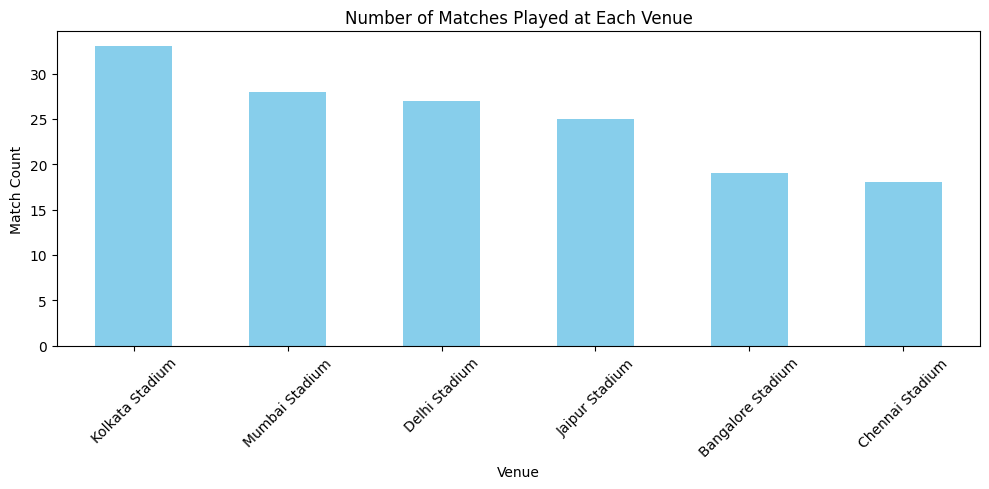

In [ ]:
import matplotlib.pyplot as plt

# Count matches per venue
newdf = df.groupby("venue")["id"].count().sort_values(ascending=False)

# Plot
newdf.plot(kind="bar", figsize=(10,5), color="skyblue")

plt.title("Number of Matches Played at Each Venue")
plt.xlabel("Venue")
plt.ylabel("Match Count")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

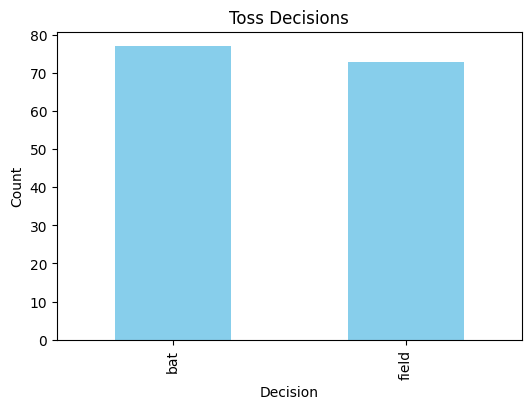

In [37]:
# Count matches per venue

# Plot
import matplotlib.pyplot as plt

df["toss_decision"].value_counts().plot(kind="bar",figsize=(6,4),color="skyblue")

plt.title("Toss Decisions")
plt.xlabel("Decision")
plt.ylabel("Count")
plt.show()

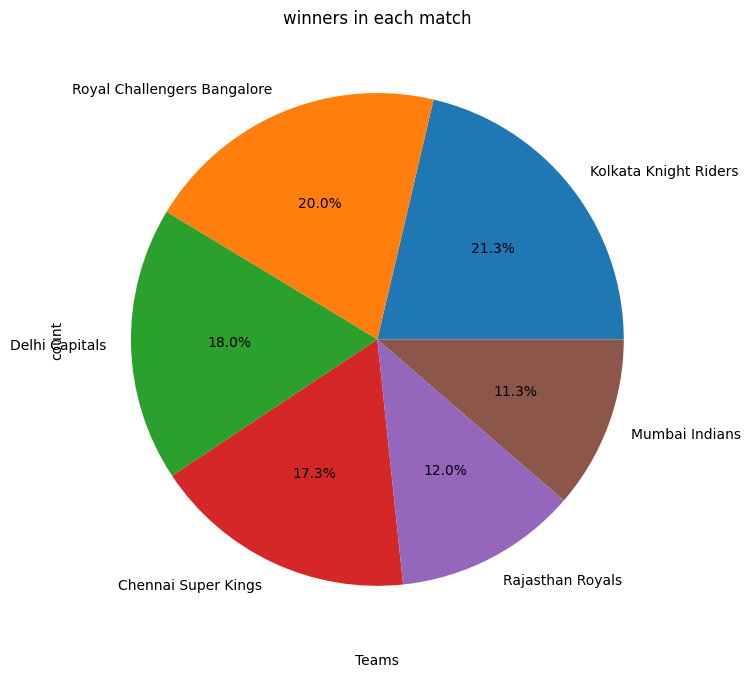

In [40]:
df["winner"].value_counts().plot(kind="pie",figsize=(8,8),color="b",autopct="%1.1f%%")
plt.title("winners in each match")
plt.xlabel("Teams")
plt.xticks(rotation=45)
plt.show()

winner
Kolkata Knight Riders          5389
Royal Challengers Bangalore    5058
Delhi Capitals                 4473
Chennai Super Kings            4429
Rajasthan Royals               2999
Mumbai Indians                 2936
Name: runs, dtype: int64


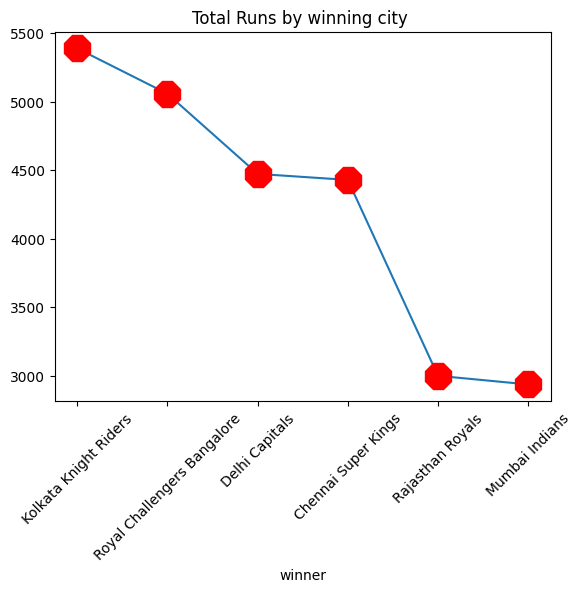

In [ ]:
newdf = df.groupby("winner")["runs"].sum().sort_values(ascending=False)
print(newdf)
newdf.plot(marker="8",ms=20,mec = 'r', mfc = 'r')
plt.title("Total Runs by winning city ")
plt.xticks(rotation=45)

plt.show()

city
Bangalore    156
Chennai      125
Mumbai       120
Jaipur       115
Kolkata       84
Delhi         76
Name: wickets, dtype: int64


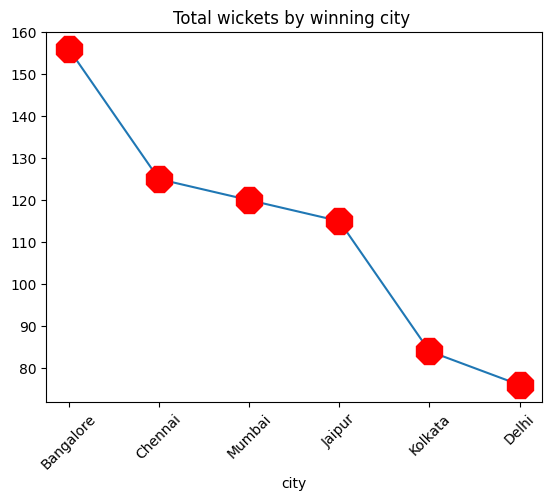

In [ ]:
newdf=df.groupby("winner")["wickets"].sum().sort_values(ascending=False)
print(newdf)
newdf.plot(marker="8",ms=20,mec = 'r', mfc = 'r')
plt.title("Total wickets by winning city ")
plt.xticks(rotation=45)

plt.show()

winner
Kolkata Knight Riders          32
Royal Challengers Bangalore    30
Delhi Capitals                 27
Chennai Super Kings            26
Rajasthan Royals               18
Mumbai Indians                 17
Name: toss_winner, dtype: int64


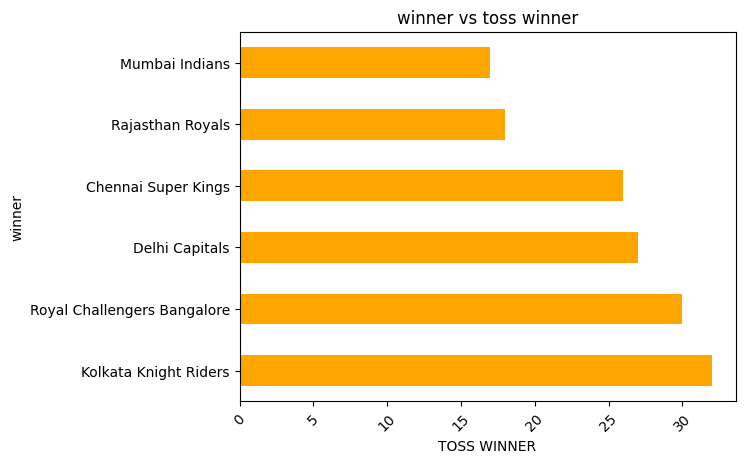

In [43]:
newdf=df.groupby("winner")["toss_winner"].count().sort_values(ascending=False)
print(newdf)
newdf.plot(kind="barh",color="orange")
plt.title("winner vs toss winner")
plt.xticks(rotation=45)
plt.xlabel("TOSS WINNER")
plt.show()

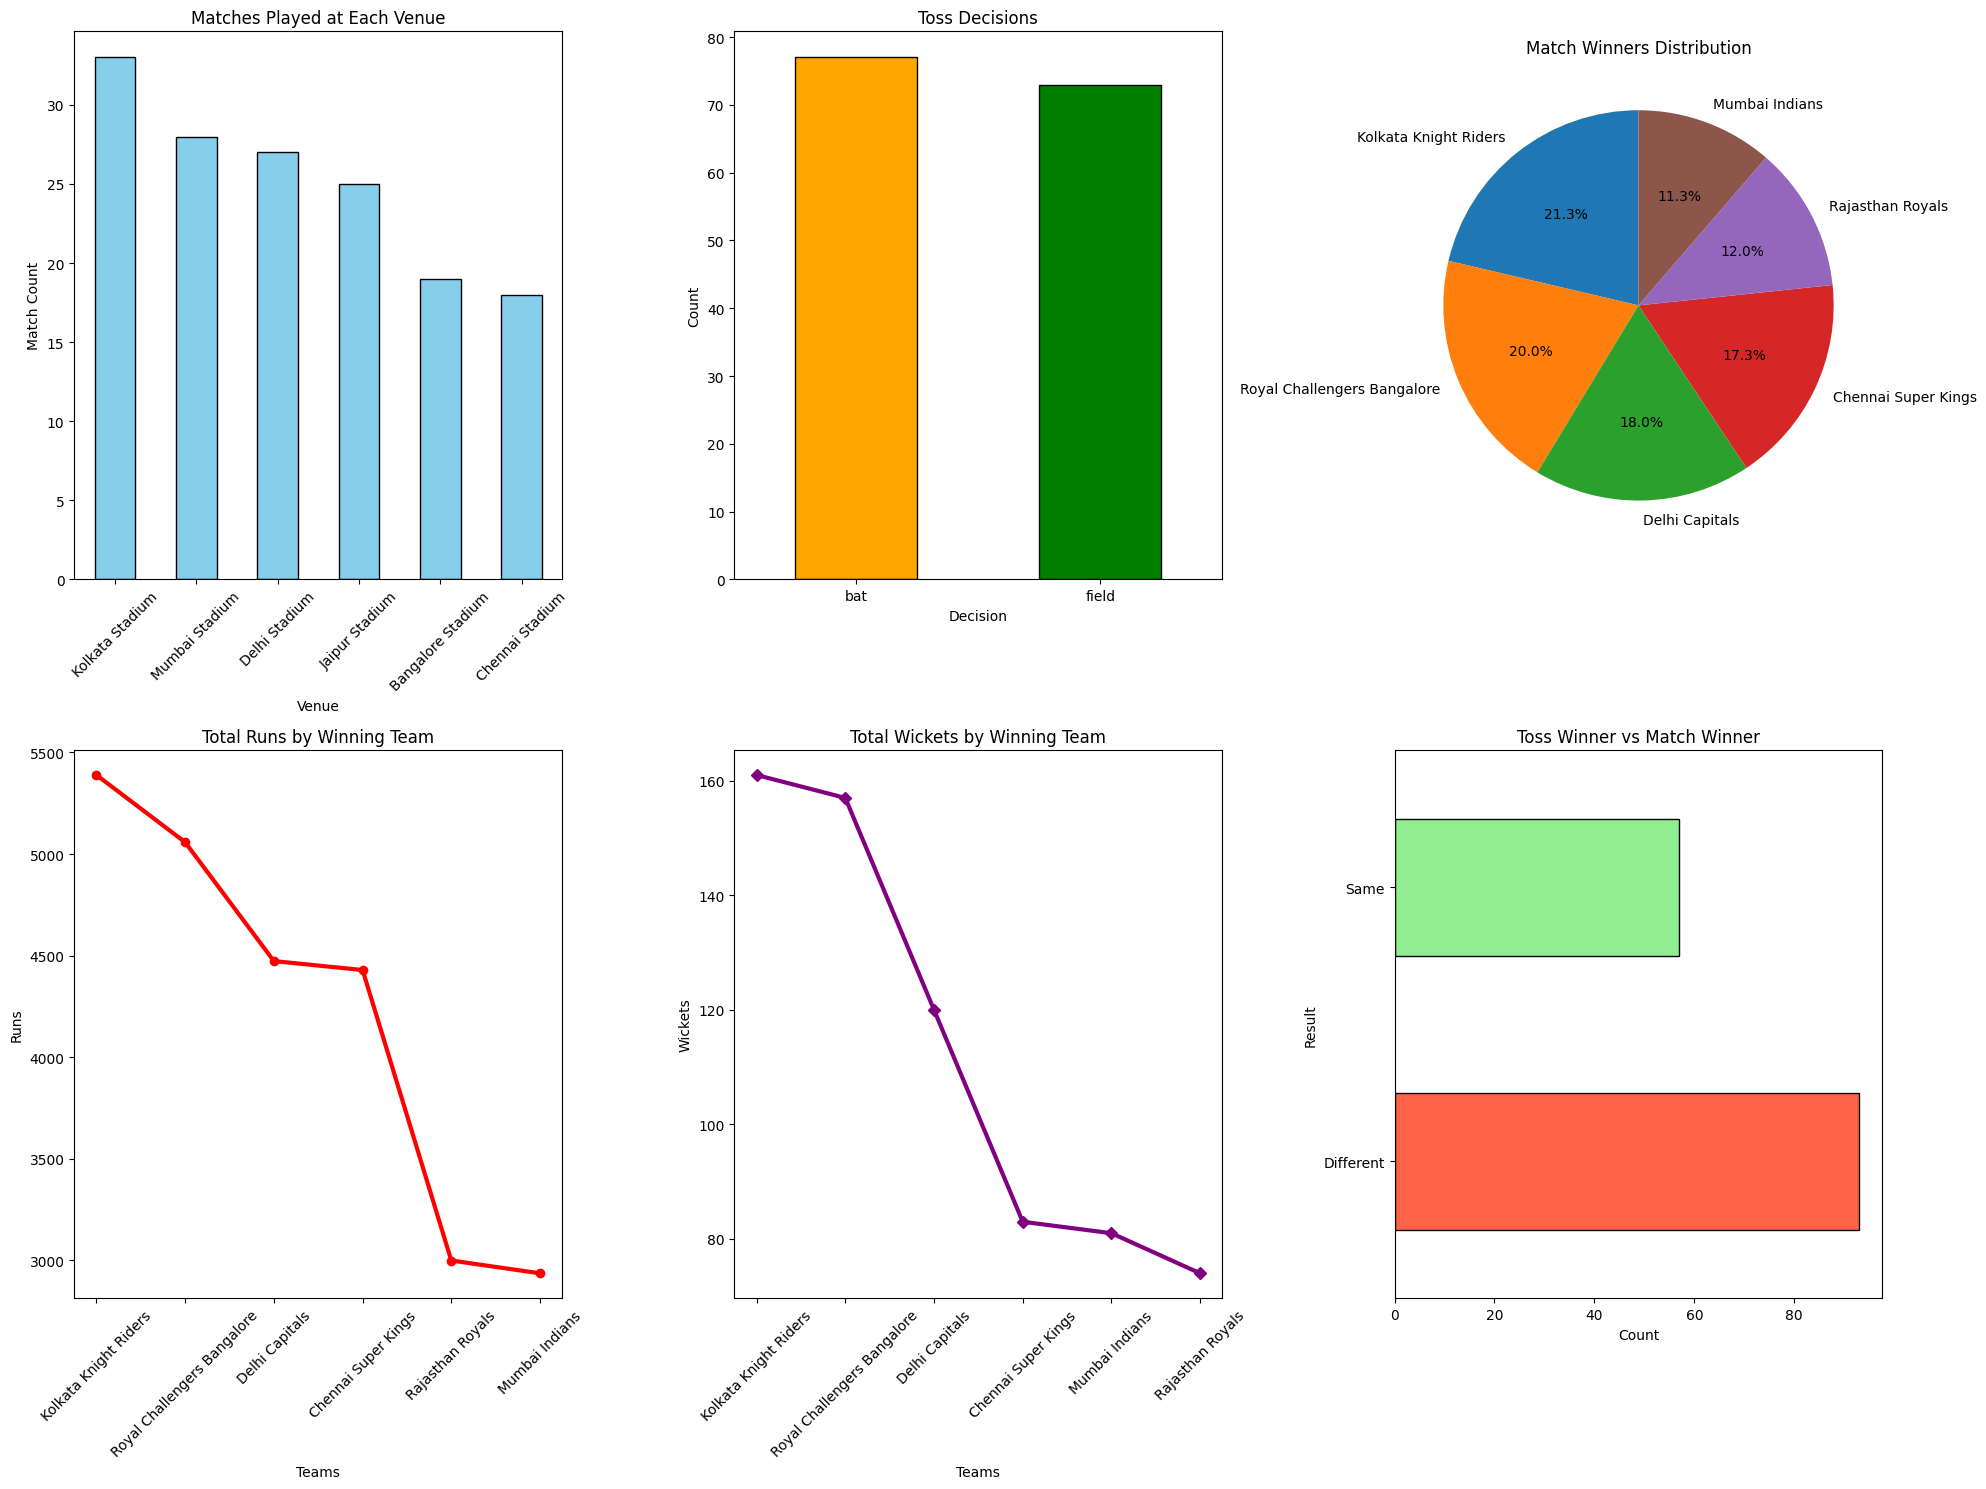

In [ ]:
import matplotlib.pyplot as plt

# -----------------------------
# DATA PREPARATION
# -----------------------------

# 1. Matches at each venue
venue_matches = df.groupby("venue")["id"].count().sort_values(ascending=False)

# 2. Toss decisions
toss_decision = df["toss_decision"].value_counts()

# 3. Match winners
winner_count = df["winner"].value_counts()

# 4. Total runs by winning team
runs_by_winner = df.groupby("winner")["runs"].sum().sort_values(ascending=False)

# 5. Total wickets by winning team
wickets_by_winner = df.groupby("winner")["wickets"].sum().sort_values(ascending=False)

# 6. Toss winner = Match winner
toss_vs_winner = (df["toss_winner"] == df["winner"]).value_counts()

# -----------------------------
# DASHBOARD LAYOUT
# -----------------------------

plt.figure(figsize=(20, 15))

# -----------------------------
# 1. VENUE MATCHES
# -----------------------------
plt.subplot(2, 3, 1)

venue_matches.plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Matches Played at Each Venue")
plt.xlabel("Venue")
plt.ylabel("Match Count")
plt.xticks(rotation=45)

# -----------------------------
# 2. TOSS DECISION
# -----------------------------
plt.subplot(2, 3, 2)

toss_decision.plot(
    kind="bar",
    color=["orange", "green"],
    edgecolor="black"
)

plt.title("Toss Decisions")
plt.xlabel("Decision")
plt.ylabel("Count")
plt.xticks(rotation=0)

# -----------------------------
# 3. WINNER DISTRIBUTION
# -----------------------------
plt.subplot(2, 3, 3)

winner_count.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Match Winners Distribution")
plt.ylabel("")

# -----------------------------
# 4. RUNS BY WINNING TEAM
# -----------------------------
plt.subplot(2, 3, 4)

runs_by_winner.plot(
    marker="o",
    linewidth=3,
    color="red"
)

plt.title("Total Runs by Winning Team")
plt.xlabel("Teams")
plt.ylabel("Runs")
plt.xticks(rotation=45)

# -----------------------------
# 5. WICKETS BY WINNING TEAM
# -----------------------------
plt.subplot(2, 3, 5)

wickets_by_winner.plot(
    marker="D",
    linewidth=3,
    color="purple"
)

plt.title("Total Wickets by Winning Team")
plt.xlabel("Teams")
plt.ylabel("Wickets")
plt.xticks(rotation=45)

# -----------------------------
# 6. TOSS WINNER VS MATCH WINNER
# -----------------------------
plt.subplot(2, 3, 6)

toss_vs_winner.index = ["Different", "Same"]

toss_vs_winner.plot(kind="barh",color=["tomato", "lightgreen"],edgecolor="black")

plt.title("Toss Winner vs Match Winner")
plt.xlabel("Count")
plt.ylabel("Result")

# -----------------------------
# FINAL TOUCH
# -----------------------------
plt.tight_layout()

plt.show()